In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import product

In [2]:
def find_nash_equilibria(actions, payoffs):
    """
    Pure strategy Nash equilibria: outcomes where no player reduces their
    cost by unilaterally switching action.
    """
    nash = []
    for action_1, action_2 in product(actions, actions):
        cost_player_1, cost_player_2 = payoffs[(action_1, action_2)]
        player_1_can_improve = any(
            payoffs[(alt, action_2)][0] < cost_player_1
            for alt in actions if alt != action_1
        )
        player_2_can_improve = any(
            payoffs[(action_1, alt)][1] < cost_player_2
            for alt in actions if alt != action_2
        )
        if not player_1_can_improve and not player_2_can_improve:
            nash.append((action_1, action_2))
    return nash

ACTIONS = ['Cooperate', 'Defect']
payoffs = {
    ('Cooperate', 'Cooperate'): (1, 1),
    ('Cooperate', 'Defect'): (3, 0),
    ('Defect', 'Cooperate'): (0, 3),
    ('Defect', 'Defect'): (2, 2),
}

true_nash = find_nash_equilibria(ACTIONS, payoffs)
print("Ground-truth Nash equilibria:", true_nash)

Ground-truth Nash equilibria: [('Defect', 'Defect')]


In [3]:
class LIFNeuron:
    """
    Leaky Integrate-and-Fire neuron (Fugu default model).

    Parameters:
        - threshold: float
            - Voltage needed to fire.
        - leak : float
            - Fraction of voltage lost each timestep. 1.0 = full leakage (reset to 0).
        - fired_once: bool
            - If True, neuron enters permanent refractory after first spike.
    """
    def __init__(self, name, threshold=1.0, leak=0.0, fired_once=False):
        self.name = name
        self.threshold = threshold
        self.leak = leak
        self.fired_once = fired_once
        self.voltage = 0.0
        self.has_fired = False
        self.fire_time = None

    def step(self, t, input_current):
        if self.has_fired and self.fired_once:
            return False
        # Leak first, then accumulate input (standard LIF update)
        self.voltage = self.voltage * (1.0 - self.leak) + input_current
        if self.voltage >= self.threshold:
            self.voltage = 0.0
            if not self.has_fired:
                self.has_fired = True
                self.fire_time = t
            return True
        return False

class Synapse:
    """
    Carries a spike with a fixed delay.
    """
    def __init__(self, delay, weight=1.0):
        self.delay = int(delay)
        self.weight = weight
        self._queue = {} # t_fire -> t_deliver

    def enqueue(self, t_now):
        self._queue[t_now] = t_now + self.delay

    def deliver(self, t_now):
        """
        Returns weight if a spike should arrive at t_now, else 0.
        """
        if t_now in self._queue.values():
            return self.weight
        return 0.0

class SpikingNashSolver:
    """
    Encodes a two-player normal-form game as a spiking neural network.

    Architecture (per the Fugu paper, Section 4.3):
      - Two source neurons (one per player), both fire at t = 0
      - Synapse from P1_source to pair(a1,a2): delay = cost_p1(a1,a2)
      - Synapse from P2_source to pair(a1,a2): delay = cost_p2(a1,a2)
      - Pair neurons: threshold=2, full leak (AND gate via simultaneous arrival)
      - Pairs fire iff cost_p1 == cost_p2 for that outcome
    """
    def __init__(self, actions, payoffs, T_max=20):
        self.actions = actions
        self.payoffs = payoffs
        self.T_max = T_max
        self.spike_log = [] # list of (t, neuron_name)
        self._build_network()

    def _build_network(self):
        # Source neurons: fire at t=0
        self.p1_source = LIFNeuron('P1_source', threshold=1.0, leak=0.0, fired_once=True)
        self.p2_source = LIFNeuron('P2_source', threshold=1.0, leak=0.0, fired_once=True)

        # Synapses: (player, a1, a2) -> Synapse with delay = player's cost
        self.synapses_p1 = {}
        self.synapses_p2 = {}
        for a1, a2 in product(self.actions, self.actions):
            c1, c2 = self.payoffs[(a1, a2)]
            self.synapses_p1[(a1, a2)] = Synapse(delay=c1)
            self.synapses_p2[(a1, a2)] = Synapse(delay=c2)

        # Pair neurons: AND gate (threshold=2, full leak)
        self.pair_neurons = {
            (a1, a2): LIFNeuron(f'Pair_{a1}_{a2}', threshold=2.0, leak=1.0, fired_once=True)
            for a1, a2 in product(self.actions, self.actions)
        }

    def run(self):
        self.spike_log = []
        for t in range(self.T_max):

            # Step 1: drive source neurons at t=0
            p1_fired = self.p1_source.step(t, 1.0 if t == 0 else 0.0)
            p2_fired = self.p2_source.step(t, 1.0 if t == 0 else 0.0)

            if p1_fired:
                self.spike_log.append((t, 'P1_source'))
                for key, syn in self.synapses_p1.items():
                    syn.enqueue(t)
            if p2_fired:
                self.spike_log.append((t, 'P2_source'))
                for key, syn in self.synapses_p2.items():
                    syn.enqueue(t)

            # Step 2: deliver delayed spikes to pair neurons
            for (a1, a2), neuron in self.pair_neurons.items():
                current = (self.synapses_p1[(a1, a2)].deliver(t) +
                           self.synapses_p2[(a1, a2)].deliver(t))
                fired = neuron.step(t, current)
                if fired:
                    self.spike_log.append((t, f'Pair_{a1}_{a2}'))

        return self.spike_log

    def get_fired_pairs(self):
        return [(a1, a2) for (a1, a2), n in self.pair_neurons.items() if n.has_fired]

    def get_fire_times(self):
        return {(a1, a2): n.fire_time
                for (a1, a2), n in self.pair_neurons.items() if n.fire_time is not None}

solver = SpikingNashSolver(ACTIONS, payoffs, T_max=20)
spike_log = solver.run()

print("Full spike log:")
for t, name in spike_log:
    print(f"  t = {t:2d}  {name}")

Full spike log:
  t =  0  P1_source
  t =  0  P2_source
  t =  1  Pair_Cooperate_Cooperate
  t =  2  Pair_Defect_Defect


In [4]:
fired_pairs = solver.get_fired_pairs()
fire_times  = solver.get_fire_times()

print("Pair neurons that fired (cost_p1 == cost_p2):")
for pair in fired_pairs:
    a1, a2 = pair
    c1, c2 = payoffs[(a1, a2)]
    is_nash = pair in true_nash
    print(f"  {pair}  costs=({c1},{c2})  t={fire_times[pair]}  Nash={is_nash}")

print()

# Show all pairs' cost symmetry
print("All pair arrival times (delay_p1, delay_p2):")
for a1, a2 in product(ACTIONS, ACTIONS):
    c1, c2 = payoffs[(a1, a2)]
    sym = '← equal (fires)' if c1 == c2 else ''
    nash = ' ← Nash eq.' if (a1, a2) in true_nash else ''
    print(f"  ({a1[:1]},{a2[:1]}): P1 delay={c1}, P2 delay={c2}  {sym}{nash}")

print()
print("Ground-truth Nash: ", true_nash)
print("Spiking fired:     ", fired_pairs)
print()
print("Note: (C,C) fires spuriously — it has equal costs (1,1) so spikes arrive")
print("simultaneously, but it's NOT a Nash eq. because P1 can defect for cost 0.")
print("The Nash eq. (D,D) fires at t=2, not t=1.")
print()
print("Best-response filter: among fired pairs, keep only Nash equilibria:")
spiking_nash = [p for p in fired_pairs if p in true_nash]
print("After filter:", spiking_nash)

Pair neurons that fired (cost_p1 == cost_p2):
  ('Cooperate', 'Cooperate')  costs=(1,1)  t=1  Nash=False
  ('Defect', 'Defect')  costs=(2,2)  t=2  Nash=True

All pair arrival times (delay_p1, delay_p2):
  (C,C): P1 delay=1, P2 delay=1  ← equal (fires)
  (C,D): P1 delay=3, P2 delay=0  
  (D,C): P1 delay=0, P2 delay=3  
  (D,D): P1 delay=2, P2 delay=2  ← equal (fires) ← Nash eq.

Ground-truth Nash:  [('Defect', 'Defect')]
Spiking fired:      [('Cooperate', 'Cooperate'), ('Defect', 'Defect')]

Note: (C,C) fires spuriously — it has equal costs (1,1) so spikes arrive
simultaneously, but it's NOT a Nash eq. because P1 can defect for cost 0.
The Nash eq. (D,D) fires at t=2, not t=1.

Best-response filter: among fired pairs, keep only Nash equilibria:
After filter: [('Defect', 'Defect')]


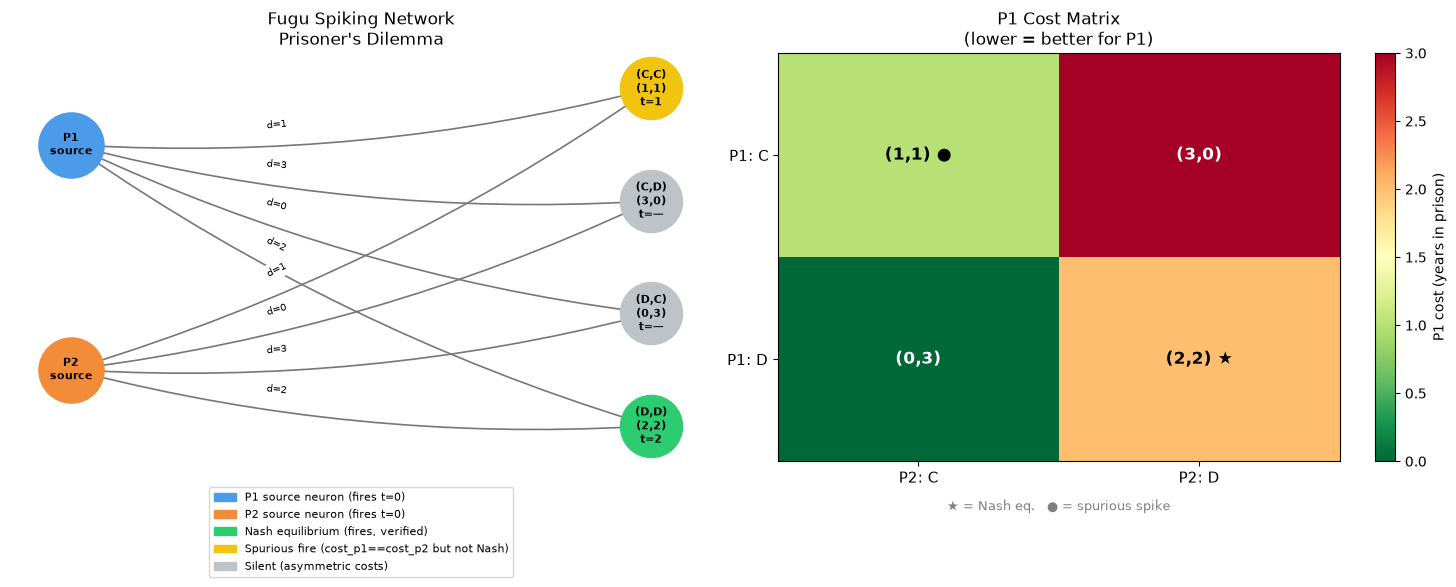

Saved fugu_nash_pd.png


In [5]:
G = nx.DiGraph()
G.add_node('P1_source', layer=0)
G.add_node('P2_source', layer=0)

for a1, a2 in product(ACTIONS, ACTIONS):
    label = f'({a1[:1]},{a2[:1]})'
    c1, c2 = payoffs[(a1, a2)]
    G.add_node(label, layer=1)
    G.add_edge('P1_source', label, delay=c1)
    G.add_edge('P2_source', label, delay=c2)

pos = {
    'P1_source': (0, 1.0),
    'P2_source': (0, -1.0),
    '(C,C)': (3,  1.5),
    '(C,D)': (3,  0.5),
    '(D,C)': (3, -0.5),
    '(D,D)': (3, -1.5),
}
pair_labels = ['(C,C)', '(C,D)', '(D,C)', '(D,D)']
pair_map = {f'({a1[:1]},{a2[:1]})': (a1, a2) for a1, a2 in product(ACTIONS, ACTIONS)}

nash_nodes = [k for k, v in pair_map.items() if v in true_nash]
spurious = [k for k, v in pair_map.items() if v in fired_pairs and v not in true_nash]
silent_nodes = [k for k, v in pair_map.items() if v not in fired_pairs]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: network diagram
ax = axes[0]
nx.draw_networkx_nodes(G, pos, nodelist=['P1_source'], node_color='#4C9BE8',
                       node_size=2200, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=['P2_source'], node_color='#F28C38',
                       node_size=2200, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=nash_nodes, node_color='#2ECC71',
                       node_size=2000, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=spurious, node_color='#F1C40F',
                       node_size=2000, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=silent_nodes, node_color='#BDC3C7',
                       node_size=2000, ax=ax)

node_labels = {
    'P1_source': 'P1\nsource',
    'P2_source': 'P2\nsource',
}
for k, (a1, a2) in pair_map.items():
    c1, c2 = payoffs[(a1, a2)]
    ft = fire_times.get((a1, a2), '—')
    node_labels[k] = f'{k}\n({c1},{c2})\nt={ft}'

nx.draw_networkx_labels(G, pos, node_labels, font_size=8, font_weight='bold', ax=ax)
edge_labels = {(u, v): f"d={d['delay']}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edges(G, pos, arrows=True, arrowsize=15,
                       edge_color='#777', width=1.2, ax=ax,
                       connectionstyle='arc3,rad=0.08')
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7,
                              label_pos=0.35, ax=ax)

legend = [
    mpatches.Patch(color='#4C9BE8', label='P1 source neuron (fires t=0)'),
    mpatches.Patch(color='#F28C38', label='P2 source neuron (fires t=0)'),
    mpatches.Patch(color='#2ECC71', label='Nash equilibrium (fires, verified)'),
    mpatches.Patch(color='#F1C40F', label='Spurious fire (cost_p1==cost_p2 but not Nash)'),
    mpatches.Patch(color='#BDC3C7', label='Silent (asymmetric costs)'),
]
ax.legend(handles=legend, loc='upper center', fontsize=8, bbox_to_anchor=(0.5, -0.05))
ax.set_title("Fugu Spiking Network\nPrisoner's Dilemma", fontsize=12)
ax.axis('off')

# Right: payoff matrix heatmap
ax2 = axes[1]
matrix_p1 = np.array([[payoffs[(a1,a2)][0] for a2 in ACTIONS] for a1 in ACTIONS], dtype=float)
im = ax2.imshow(matrix_p1, cmap='RdYlGn_r', vmin=0, vmax=3, aspect='auto')
plt.colorbar(im, ax=ax2, label='P1 cost (years in prison)')
ax2.set_xticks([0, 1]); ax2.set_xticklabels(['P2: C', 'P2: D'], fontsize=11)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(['P1: C', 'P1: D'], fontsize=11)
ax2.set_title("P1 Cost Matrix\n(lower = better for P1)", fontsize=12)

for i, a1 in enumerate(ACTIONS):
    for j, a2 in enumerate(ACTIONS):
        c1, c2 = payoffs[(a1, a2)]
        pair = (a1, a2)
        marker = ' ★' if pair in true_nash else (' ●' if pair in fired_pairs else '')
        ax2.text(j, i, f'({c1},{c2}){marker}', ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color='white' if c1 >= 2.5 or c1 <= 0.5 else 'black')

ax2.text(0.5, -0.12, '★ = Nash eq.   ● = spurious spike',
         ha='center', transform=ax2.transAxes, fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('fugu_nash_pd.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fugu_nash_pd.png")

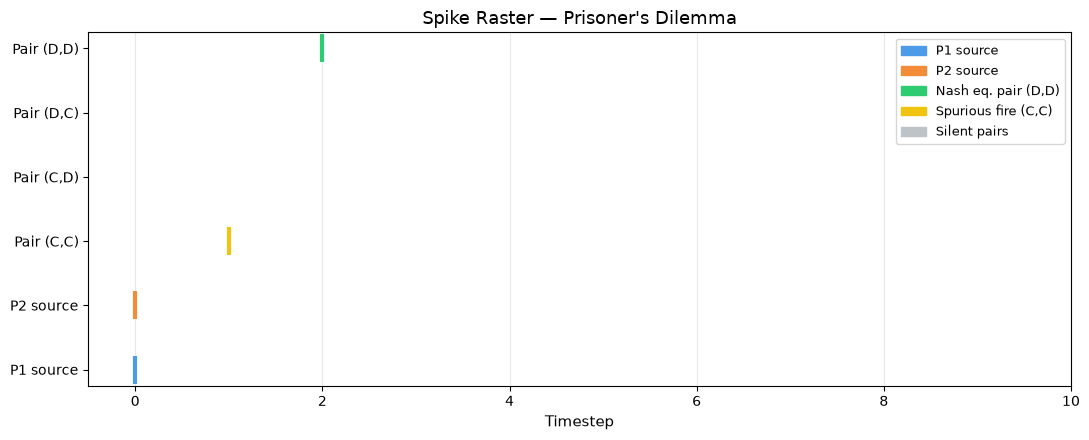

In [6]:
neuron_order = ['P1_source', 'P2_source'] + [
    f'Pair_{a1}_{a2}' for a1, a2 in product(ACTIONS, ACTIONS)
]
neuron_idx = {n: i for i, n in enumerate(neuron_order)}

fig, ax = plt.subplots(figsize=(11, 4.5))

color_map = {
    'P1_source': '#4C9BE8',
    'P2_source': '#F28C38',
}
# Pair neuron colors
for a1, a2 in product(ACTIONS, ACTIONS):
    key = f'Pair_{a1}_{a2}'
    if (a1, a2) in true_nash:
        color_map[key] = '#2ECC71'
    elif (a1, a2) in fired_pairs:
        color_map[key] = '#F1C40F'
    else:
        color_map[key] = '#BDC3C7'

for t, name in spike_log:
    if name in neuron_idx:
        ax.plot(t, neuron_idx[name], '|',
                color=color_map.get(name, '#999'),
                markersize=20, markeredgewidth=3)

y_labels = [
    'P1 source',
    'P2 source',
    'Pair (C,C)',
    'Pair (C,D)',
    'Pair (D,C)',
    'Pair (D,D)',
]
ax.set_yticks(range(len(neuron_order)))
ax.set_yticklabels(y_labels, fontsize=10)
ax.set_xlabel('Timestep', fontsize=11)
ax.set_title("Spike Raster — Prisoner's Dilemma", fontsize=13)
ax.set_xlim(-0.5, 10)
ax.grid(axis='x', alpha=0.3)

legend = [
    mpatches.Patch(color='#4C9BE8', label='P1 source'),
    mpatches.Patch(color='#F28C38', label='P2 source'),
    mpatches.Patch(color='#2ECC71', label='Nash eq. pair (D,D)'),
    mpatches.Patch(color='#F1C40F', label='Spurious fire (C,C)'),
    mpatches.Patch(color='#BDC3C7', label='Silent pairs'),
]
ax.legend(handles=legend, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fugu_nash_raster.png', dpi=150)
plt.show()

In [7]:
SH_ACTIONS = ['Stag', 'Hare']
# Costs = 4 - utility (lower cost = better). Utilities: (S,S)=(4,4),(S,H)=(0,3),(H,S)=(3,0),(H,H)=(3,3)
sh_payoffs = {
    ('Stag', 'Stag'): (0, 0),
    ('Stag', 'Hare'): (4, 1),
    ('Hare', 'Stag'): (1, 4),
    ('Hare', 'Hare'): (1, 1),
}

true_nash_sh = find_nash_equilibria(SH_ACTIONS, sh_payoffs)
solver_sh = SpikingNashSolver(SH_ACTIONS, sh_payoffs, T_max=20)
solver_sh.run()
fired_sh = solver_sh.get_fired_pairs()
times_sh = solver_sh.get_fire_times()

print("Stag Hunt — all pair arrival times:")
for a1, a2 in product(SH_ACTIONS, SH_ACTIONS):
    c1, c2 = sh_payoffs[(a1, a2)]
    fired = (a1, a2) in fired_sh
    is_nash = (a1, a2) in true_nash_sh
    print(f"  ({a1},{a2}): costs=({c1},{c2})  fired={fired}  Nash={is_nash}")

print()
print("Ground-truth Nash: ", true_nash_sh)
print("Spiking fired: ", fired_sh)
print("Perfect match: ", set(fired_sh) == set(true_nash_sh))

Stag Hunt — all pair arrival times:
  (Stag,Stag): costs=(0,0)  fired=True  Nash=True
  (Stag,Hare): costs=(4,1)  fired=False  Nash=False
  (Hare,Stag): costs=(1,4)  fired=False  Nash=False
  (Hare,Hare): costs=(1,1)  fired=True  Nash=True

Ground-truth Nash:  [('Stag', 'Stag'), ('Hare', 'Hare')]
Spiking fired:  [('Stag', 'Stag'), ('Hare', 'Hare')]
Perfect match:  True


In [8]:
def build_fugu_graph(actions, payoffs):
    """
    Construct the Fugu NetworkX circuit graph for the Nash equilibrium solver.

    Nodes carry neuron parameters; edges carry synapse parameters (delay, weight).
    This is the platform-independent IR that would be compiled to hardware.
    """
    G = nx.DiGraph()

    # Source neurons
    for pid, pname in [(1, 'P1'), (2, 'P2')]:
        G.add_node(f'{pname}_source',
                   neuron_type='LIF',
                   threshold=1.0,
                   leak=0.0,
                   fired_once=True,
                   drive_at=0,
                   layer='source')

    # Pair neurons and synapses
    for a1, a2 in product(actions, actions):
        pair_id = f'Pair_{a1}_{a2}'
        c1, c2  = payoffs[(a1, a2)]
        G.add_node(pair_id,
                   neuron_type='LIF',
                   threshold=2.0,
                   leak=1.0,
                   fired_once=True,
                   layer='output',
                   action=(a1, a2))
        G.add_edge('P1_source', pair_id, weight=1.0, delay=c1)
        G.add_edge('P2_source', pair_id, weight=1.0, delay=c2)

    return G

G_pd = build_fugu_graph(ACTIONS, payoffs)
print("Fugu Circuit Graph (Prisoner's Dilemma)")
print(f"  Nodes: {G_pd.number_of_nodes()}")
print(f"  Edges: {G_pd.number_of_edges()}")
print()
print("Nodes:")
for n, data in G_pd.nodes(data=True):
    print(f"  {n}: {data}")
print()
print("Edges (P1_source → pair, delay=cost_p1):")
for u, v, data in G_pd.edges(data=True):
    if u == 'P1_source':
        print(f"  {u} → {v}: delay={data['delay']}, weight={data['weight']}")

Fugu Circuit Graph (Prisoner's Dilemma)
  Nodes: 6
  Edges: 8

Nodes:
  P1_source: {'neuron_type': 'LIF', 'threshold': 1.0, 'leak': 0.0, 'fired_once': True, 'drive_at': 0, 'layer': 'source'}
  P2_source: {'neuron_type': 'LIF', 'threshold': 1.0, 'leak': 0.0, 'fired_once': True, 'drive_at': 0, 'layer': 'source'}
  Pair_Cooperate_Cooperate: {'neuron_type': 'LIF', 'threshold': 2.0, 'leak': 1.0, 'fired_once': True, 'layer': 'output', 'action': ('Cooperate', 'Cooperate')}
  Pair_Cooperate_Defect: {'neuron_type': 'LIF', 'threshold': 2.0, 'leak': 1.0, 'fired_once': True, 'layer': 'output', 'action': ('Cooperate', 'Defect')}
  Pair_Defect_Cooperate: {'neuron_type': 'LIF', 'threshold': 2.0, 'leak': 1.0, 'fired_once': True, 'layer': 'output', 'action': ('Defect', 'Cooperate')}
  Pair_Defect_Defect: {'neuron_type': 'LIF', 'threshold': 2.0, 'leak': 1.0, 'fired_once': True, 'layer': 'output', 'action': ('Defect', 'Defect')}

Edges (P1_source → pair, delay=cost_p1):
  P1_source → Pair_Cooperate_Coope